# Snow Cover Mapping with VIIRS

This notebook uses data from the Visible Infrared Imaging Radiometer Suite (VIIRS) to create a simple map of snow cover. Because this is NASA data, we can use `earthaccess` to quickly access a few images of interest.

Credit goes to Justin Pflug for the snow cover processing code.

In [10]:
!pip install contextily

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mercantile-1.2.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
Using cached mercantile-1.2.1-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contextily]


In [1]:
import earthaccess
import geopandas as gpd
import glob
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import h5py
import numpy as np
import datetime
import contextily as cx

The VIIRS snow cover data is available through NSIDC, so we are capable of streaming it directly through the cloud. Let's start with a simple example using only a single file.

According to its NSIDC webpage (https://nsidc.org/data/vj110a1f/versions/2), the short name for the VIIRS snow cover product is `VJ110A1F`. We will look at an image that includes Fairbanks, AK during the SnowEx campaign in March 2023.

In [2]:
# Authenticate with earthaccess
earthaccess.login()

In [12]:
# Convert Fairbanks geoJSON to earthaccess-friendly format.
fairbanks = gpd.read_file("/home/jovyan/snow-observations-cookbook/notebooks/data/cffl_lidar_box.geojson")
fairbanks.to_crs("EPSG:4326", inplace=True)
minx, miny, maxx, maxy = fairbanks.total_bounds

# Run the earthaccess query
results = earthaccess.search_data(
    short_name='VJ110A1F',
    bounding_box=(minx, miny, maxx, maxy),
    temporal=("2023-03-01", "2023-03-31"),
    count=10
)

In [21]:
results

[Collection: {'EntryTitle': 'VIIRS/JPSS1 CGF Snow Cover Daily L3 Global 375m SIN Grid V002'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -174.4879, 'Latitude': 57.5583}, {'Longitude': -140.11, 'Latitude': 59.6453}, {'Longitude': -135.9269, 'Latitude': 69.2114}, {'Longitude': 176.5451, 'Latitude': 66.3568}, {'Longitude': -174.4879, 'Latitude': 57.5583}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-03-01T00:00:00.000Z', 'EndingDateTime': '2023-03-01T23:59:59.000Z'}}
 Size(MB): 3.26094913482666
 Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/VIIRS/VJ110A1F/2/2023/03/01/VJ110A1F.A2023060.h10v02.002.2023100165849.h5'],
 Collection: {'EntryTitle': 'VIIRS/JPSS1 CGF Snow Cover Daily L3 Global 375m SIN Grid V002'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -161.9998, 'Latitude': 55.5345}, {'Longit

In [4]:
display(results[1])

Collection: {'EntryTitle': 'VIIRS/JPSS1 CGF Snow Cover Daily L3 Global 375m SIN Grid V002'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -161.9998, 'Latitude': 55.5345}, {'Longitude': -120.1018, 'Latitude': 59.6807}, {'Longitude': -109.9069, 'Latitude': 75.5554}, {'Longitude': 176.2111, 'Latitude': 68.4671}, {'Longitude': -161.9998, 'Latitude': 55.5345}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-03-01T00:00:00.000Z', 'EndingDateTime': '2023-03-01T23:59:59.000Z'}}
Size(MB): 6.94252300262451
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/VIIRS/VJ110A1F/2/2023/03/01/VJ110A1F.A2023060.h11v02.002.2023100170958.h5']

Since we are looking at a large area over a month, we have several files available for analysis. To start, we will only look at one file, to demonstrate how we would load and plot the snow cover data.

In [6]:
# Stream the data directly into memory
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

VIIRS snow cover data is provided in HDF-5 format, with a customized GIS projection. Neither setup is ideal for a simple plot, so we will start by defining functions that will make data visualizing easier.

In [7]:
# Function to identify coordinates and snow cover data
def assign_and_grid(ds):
    with h5py.File(files[1],'r') as f:
        x = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['XDim'][:] # X-coordinates
        y = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['YDim'][:] # Y-coordinates
        data = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['Data Fields']['CGF_NDSI_Snow_Cover'][:] # Snow cover

    # Create coordinate arrays (adjust if you need a specific dimension order)
    coords = {'x': x, 'y': y}
    # Create the xarray dataset
    ds = xr.DataArray(data, coords=coords, dims=['y', 'x'])
    # If you need to create a full Dataset (not just a DataArray), you can do:
    ds = ds.to_dataset(name='CGF_NDSI_Snow_Cover')
    return ds

# Ensure that the data has a defined CRS, prior to reprojection
def reproject_func(ds,var,dom_ref,x_lims,y_lims):
    ds = ds[var]
    ds.rio.write_crs("PROJCS[\"MODIS Sinusoidal\",GEOGCS[\"GCS_unnamed ellipse\",DATUM[\"D_unknown\",SPHEROID[\"Unknown\",6371007.181,0]],PRIMEM[\"Greenwich\",0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Sinusoidal\"],PARAMETER[\"false_easting\",0.0],PARAMETER[\"false_northing\",0.0],PARAMETER[\"central_meridian\",0.0],UNIT[\"Meter\",1.0]]", inplace=True)
    #ds = ds.sel(x=slice(x_lims[0],x_lims[1]),y=slice(y_lims[1],y_lims[0]))
    return ds

In [8]:
# Open the data in raster format, to define domain limits
dom_ref = rxr.open_rasterio(files[0]).isel(band=0).rio.write_crs(4326)

# Define domain limits
buffer = 5000
lim_test = dom_ref.rio.reproject("PROJCS[\"MODIS Sinusoidal\",GEOGCS[\"GCS_unnamed ellipse\",DATUM[\"D_unknown\",SPHEROID[\"Unknown\",6371007.181,0]],PRIMEM[\"Greenwich\",0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Sinusoidal\"],PARAMETER[\"false_easting\",0.0],PARAMETER[\"false_northing\",0.0],PARAMETER[\"central_meridian\",0.0],UNIT[\"Meter\",1.0]]")
x_lims = [lim_test.x.mean().values-buffer,lim_test.x.mean().values+buffer]
y_lims = [lim_test.y.mean().values-buffer,lim_test.y.mean().values+buffer]
print(x_lims,y_lims)

/srv/conda/envs/notebook/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/srv/conda/envs/notebook/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_w

[-5336.126162767178, 4663.873837232822] [4998744.042501327, 5008744.042501327]


In [9]:
try:
    # Load and pre-process VIIRS data
    ds = xr.open_dataset(files[0])
    ds = assign_and_grid(ds)
    ds = reproject_func(ds,'CGF_NDSI_Snow_Cover',dom_ref,x_lims,y_lims)
    
    # Filter data to include realistic values
    ds = ds.where(ds <= 100)

    if len(ds.values[~np.isnan(ds.values)]) > 0:
        print(ds.shape)
except:
    print('Error: Unable to process file.')

(3000, 3000)


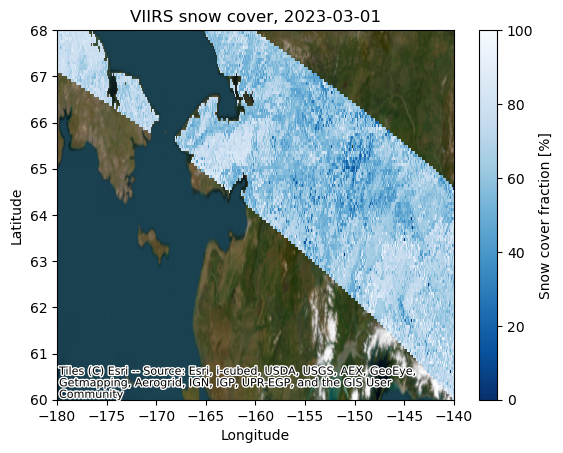

In [35]:
# Get date of data granule
date = dom_ref.attrs['StartTime'][:10]

# Plot VIIRS snow cover over ESRI imagery
fig, ax = plt.subplots()
ds.rio.reproject(4326).plot(ax=ax, vmin=0, vmax=100, cmap="Blues_r",
                            cbar_kwargs={'label': "Snow cover fraction [%]"})
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"VIIRS snow cover, {date}")
ax.set_xlim(-180, -140)
ax.set_ylim(60, 68)
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery, zoom=8)

In [53]:
domain_id = 7
trial_id = 33
water_year = 2023
multi_tile = 0

domains_direc = '/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/ASO/selected/'
pathh = '/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/'
pathh += 'domain'+str(domain_id).zfill(2)+'_trial'+str(trial_id).zfill(2)+'/'

short_name = 'VNP10A1F'
var = 'CGF_NDSI_Snow_Cover'
buffer = 5000

In [55]:
def assign_and_grid(ds):
    with h5py.File(file,'r') as f:
        x = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['XDim'][:]
        y = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['YDim'][:]
        data = f['HDFEOS']['GRIDS']['VIIRS_Grid_IMG_2D']['Data Fields']['CGF_NDSI_Snow_Cover'][:]

    # Create coordinate arrays (adjust if you need a specific dimension order)
    coords = {'x': x, 'y': y}
    # Create the xarray dataset
    ds = xr.DataArray(data, coords=coords, dims=['y', 'x'])
    # If you need to create a full Dataset (not just a DataArray), you can do:
    ds = ds.to_dataset(name='CGF_NDSI_Snow_Cover')
    return ds

def reproject_func(ds,var,dom_ref,x_lims,y_lims):
    ds = ds[var]
    ds.rio.write_crs("PROJCS[\"MODIS Sinusoidal\",GEOGCS[\"GCS_unnamed ellipse\",DATUM[\"D_unknown\",SPHEROID[\"Unknown\",6371007.181,0]],PRIMEM[\"Greenwich\",0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Sinusoidal\"],PARAMETER[\"false_easting\",0.0],PARAMETER[\"false_northing\",0.0],PARAMETER[\"central_meridian\",0.0],UNIT[\"Meter\",1.0]]", inplace=True)
#     ds = ds.rio.reproject(dom_ref.rio.crs)
#     ds.rio.reproject_match(dom_ref).plot(vmax=100)
    ds = ds.sel(x=slice(x_lims[0],x_lims[1]),y=slice(y_lims[1],y_lims[0]))
    return ds

## Working with multiple VIIRS files
The above example demonstrates that we can use `earthaccess` to quickly access VIIRS snow cover data, but it only considers one swath data.

If one looks closely to our original query, we actually retrieved 10 files over the domain of interest. Let's see if we can utilize all of those files for a more detailed analysis.

In [56]:
date_list = []
ds_concat = []
for fCount,file in enumerate(viirs_files):
    print(file)
    
    try:
        ds = xr.open_dataset(file, engine="netcdf4")
        ds = assign_and_grid(ds)
        ds = reproject_func(ds,var,dom_ref,x_lims,y_lims)
        ds = ds.where(ds <= 100)

        if len(ds.values[~np.isnan(ds.values)]) > 0:
            print(ds.shape)
#             fg,ax = plt.subplots()
#             ds.plot(ax=ax,vmin=0,vmax=100)
#             ax.set_title(fCount)

            subsamp = file.split('/')[-1].split('.')[1]
            date_list.append(np.datetime64(datetime.date(int(subsamp[1:5]),1,1)+datetime.timedelta(days=int(subsamp[5:9])-1)))
            ds_concat.append(ds)
    except:
        print('potentially corrupted file?')
      
#     if fCount == 1:
#         break

ds_concat = xr.concat(ds_concat,dim="time")
ds_concat['time'] = ('time', date_list)

/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022244.h09v05.002.2023056014852.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022245.h09v05.002.2023056041525.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022246.h09v05.002.2023056062557.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022247.h09v05.002.2023056083626.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022248.h09v05.002.2023056103741.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022249.h09v05.002.2023056125951.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022250.h09v05.002.2023056145652.h5
(27, 27)
/Users/jpflug/Documents/Projects/s

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022305.h09v05.002.2023069125838.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022306.h09v05.002.2023069141343.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022307.h09v05.002.2023069160944.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022308.h09v05.002.2023069174310.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022309.h09v05.002.2023069192112.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022310.h09v05.002.2023069205315.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2022311.h09v05.002.2023069223743.h5
(27, 27)
/Users/jpflug/Documents/P

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023002.h09v05.002.2023093170555.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023003.h09v05.002.2023093191501.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023004.h09v05.002.2023093210257.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023005.h09v05.002.2023093224804.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023006.h09v05.002.2023094004142.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023007.h09v05.002.2023094023156.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023008.h09v05.002.2023094043533.h5
(27, 27)
/Users/jpflug/Documents/P

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023062.h09v05.002.2023101031131.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023063.h09v05.002.2023101051041.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023064.h09v05.002.2023101070035.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023065.h09v05.002.2023101084032.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023066.h09v05.002.2023101100735.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023067.h09v05.002.2023101113103.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023068.h09v05.002.2023101125634.h5
(27, 27)
/Users/jpflug/Documents/P

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023122.h09v05.002.2023131205834.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023123.h09v05.002.2023131224842.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023124.h09v05.002.2023132002501.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023125.h09v05.002.2023132024636.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023126.h09v05.002.2023132045900.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023127.h09v05.002.2023132065733.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023128.h09v05.002.2023132162630.h5
(27, 27)
/Users/jpflug/Documents/P

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023183.h09v05.002.2023184091937.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023184.h09v05.002.2023185104013.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023185.h09v05.002.2023186101452.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023186.h09v05.002.2023187193252.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023187.h09v05.002.2023188103704.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023188.h09v05.002.2023191011859.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023189.h09v05.002.2023191072840.h5
(27, 27)
/Users/jpflug/Documents/P

(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023243.h09v05.002.2023244092915.h5
(27, 27)
/Users/jpflug/Documents/Projects/snowCover_comparisons/Data/VIIRS/domain07_trial33/VNP10A1F.A2023244.h09v05.002.2023245092340.h5
(27, 27)


In [57]:
if multi_tile:
    # Group by unique times
    grouped = ds_concat.groupby('time')

    # Apply nanmean to each group, keeping it as an xarray.DataArray
    ds_concat = grouped.map(
        lambda group: xr.DataArray(
            np.nanmean(group, axis=0),  # Compute nanmean along the time axis
            dims=group.dims[1:],       # Keep the original spatial dimensions
            coords={dim: group.coords[dim] for dim in group.dims[1:]}  # Preserve coordinates
        )
    )

    # Check the resulting DataArray
    # print(ds_concat)

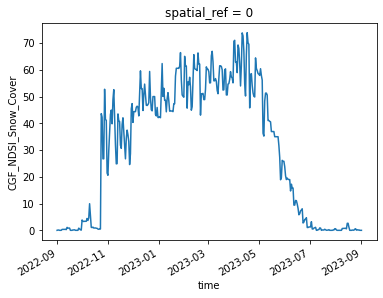

In [58]:
ds_concat.mean(dim=('x','y')).plot()

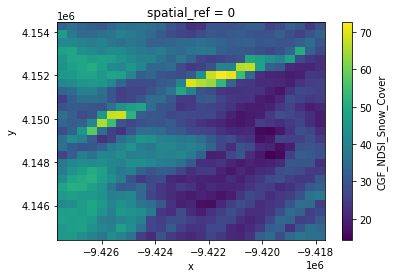

In [59]:
ds_concat.mean(dim='time').plot()